**Spaceship Titanic – Machine Learning Project**

This project analyzes the Spaceship Titanic dataset to predict whether a passenger was transported to another dimension during an interstellar anomaly. The task is a binary classification problem where the target variable indicates whether a passenger was transported or not.

The dataset contains passenger attributes such as home planet, destination, cabin location, age, VIP status, cryosleep status, and spending on onboard services including room service, food court, shopping mall, spa, and VR deck. These features provide behavioral and demographic information that may influence transportation outcomes.

The project follows a complete machine learning workflow including data cleaning, feature engineering, model training, and prediction generation. During preprocessing, missing values are handled and categorical variables are transformed into numerical representations suitable for machine learning algorithms.

Feature engineering is applied to extract additional information from the dataset. Spending-related columns are combined to create a total spending feature, and a no-spending indicator is introduced to capture passenger behavior. The cabin column is split into deck, cabin number, and side to represent passenger location within the spaceship. Passenger groups are also derived from the PassengerId column to estimate group travel behavior.

After feature preparation, classification models are trained to learn patterns associated with transportation outcomes. The trained model is then used to generate predictions for the test dataset. Finally, the predictions are formatted into a submission file containing PassengerId and the predicted transport status, which can be uploaded for evaluation on Kaggle.


### Dataset

The dataset used in this project comes from the Spaceship Titanic competition on Kaggle. It contains passenger records from an interstellar passenger ship where an anomaly caused some travelers to be transported to another dimension.

The dataset consists of two files: a training dataset and a test dataset. The training dataset includes the target variable **Transported**, which indicates whether a passenger was transported or not. The test dataset contains the same passenger features but does not include the target variable, and it is used to generate predictions for evaluation.

Key features in the dataset include passenger demographic information, travel details, and onboard spending behavior. Important columns include **HomePlanet**, **Destination**, **Age**, **VIP status**, **CryoSleep**, and spending across different ship services such as **RoomService**, **FoodCourt**, **ShoppingMall**, **Spa**, and **VRDeck**. The **Cabin** column contains structured location information within the spaceship, which can be further split into deck, cabin number, and side.

The dataset also contains a **PassengerId** column that uniquely identifies each passenger and encodes group information for passengers traveling together. This information can be used for feature engineering to capture group behavior and improve model performance.


In [41]:
import pandas as pd
import numpy as np

In [42]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

The training and test datasets are loaded using pandas. 
The training dataset contains the target variable "Transported", 
while the test dataset is used to generate predictions for submission.

In [43]:
train.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [44]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


In [45]:
train.isnull().sum()

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

In [46]:
train["Transported"].value_counts()

Transported
True     4378
False    4315
Name: count, dtype: int64

In [47]:
train.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


## Data Cleaning
In this step we handle missing values and prepare the dataset for feature engineering and model training. Proper data cleaning ensures the model receives consistent and meaningful input data.

In [48]:
train.isnull().sum()

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

In [49]:
test.isnull().sum()

PassengerId       0
HomePlanet       87
CryoSleep        93
Cabin           100
Destination      92
Age              91
VIP              93
RoomService      82
FoodCourt       106
ShoppingMall     98
Spa             101
VRDeck           80
Name             94
dtype: int64

In [50]:
train["Age"].fillna(train["Age"].median(), inplace=True)
test["Age"].fillna(test["Age"].median(), inplace=True)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_11312\2963239186.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train["Age"].fillna(train["Age"].median(), inplace=True)
C:\Users\Administrator\AppData\Local\Temp\ipykernel_11312\2963239186.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always beh

In [51]:
cols = ["HomePlanet","Destination","CryoSleep","VIP"]

for col in cols:
    train[col].fillna(train[col].mode()[0], inplace=True)
    test[col].fillna(test[col].mode()[0], inplace=True)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_11312\2200546346.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train[col].fillna(train[col].mode()[0], inplace=True)
C:\Users\Administrator\AppData\Local\Temp\ipykernel_11312\2200546346.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behave

In [52]:
spend_cols = ["RoomService","FoodCourt","ShoppingMall","Spa","VRDeck"]

for col in spend_cols:
    train[col].fillna(0, inplace=True)
    test[col].fillna(0, inplace=True)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_11312\3902393334.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train[col].fillna(0, inplace=True)
C:\Users\Administrator\AppData\Local\Temp\ipykernel_11312\3902393334.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For e

In [53]:
train.drop("Name", axis=1, inplace=True)
test.drop("Name", axis=1, inplace=True)

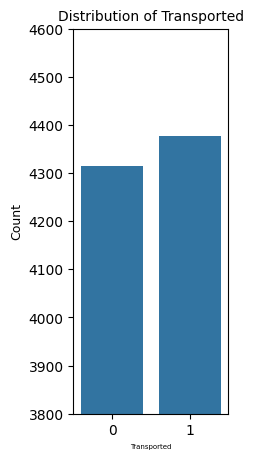

In [92]:
# Target Distribution (smaller plot)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(2,5))   # width, height in inches
sns.countplot(x="Transported", data=train)

plt.title("Distribution of Transported", fontsize=10)
plt.xlabel("Transported", fontsize=5)
plt.ylabel("Count", fontsize=9)
plt.ylim(3800, 4600)
plt.show()

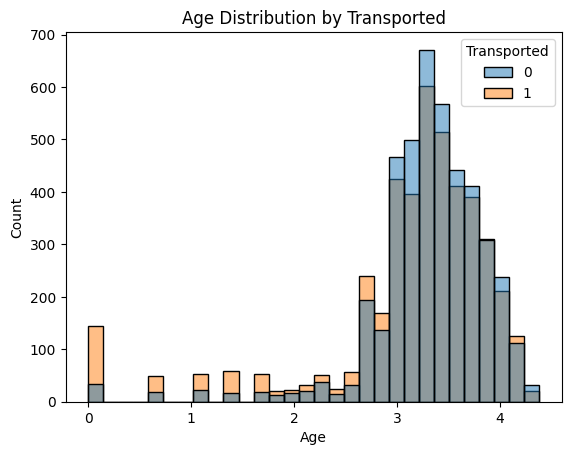

In [77]:
sns.histplot(data=train, x="Age", hue="Transported", bins=30)
plt.title("Age Distribution by Transported")
plt.show()

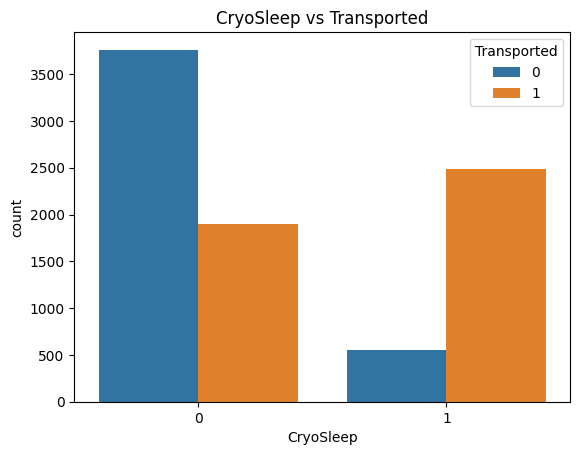

In [78]:
sns.countplot(x="CryoSleep", hue="Transported", data=train)
plt.title("CryoSleep vs Transported")
plt.show()

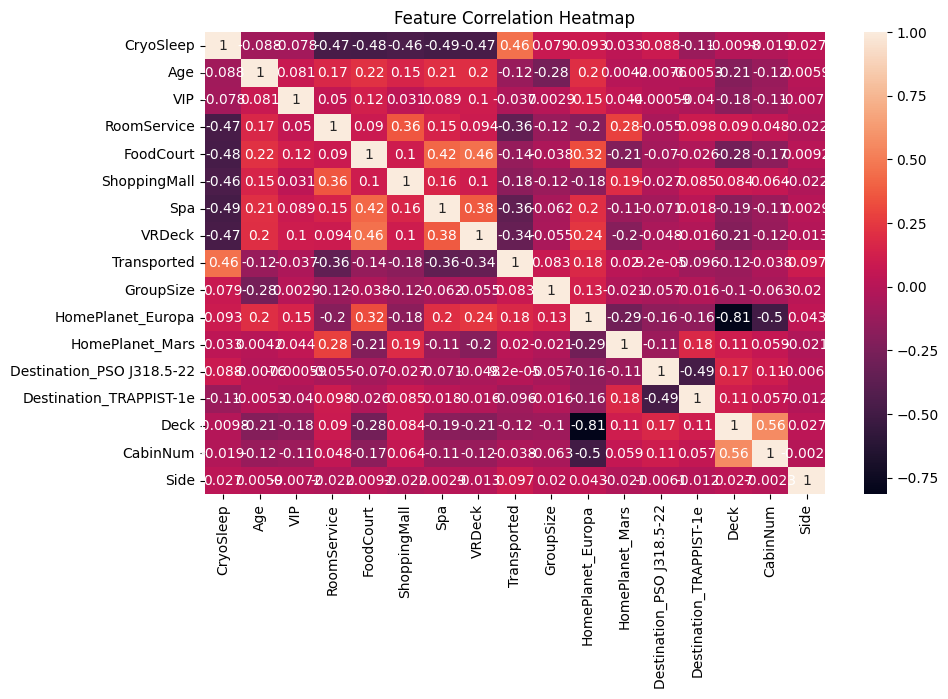

In [79]:
plt.figure(figsize=(10,6))
sns.heatmap(train.corr(numeric_only=True), annot=True)
plt.title("Feature Correlation Heatmap")
plt.show()

## Feature Engineering
In this step new features are created from existing variables to help the model capture hidden patterns in the data.

In [56]:
train["Group"] = train["PassengerId"].str.split("_").str[0]
test["Group"] = test["PassengerId"].str.split("_").str[0]

In [57]:
train["GroupSize"] = train.groupby("Group")["Group"].transform("count")
test["GroupSize"] = test.groupby("Group")["Group"].transform("count")

In [58]:
train.drop("Group",axis=1,inplace=True)
test.drop("Group",axis=1,inplace=True)

In [59]:
train["CryoSleep"] = train["CryoSleep"].astype(int)
test["CryoSleep"] = test["CryoSleep"].astype(int)

train["VIP"] = train["VIP"].astype(int)
test["VIP"] = test["VIP"].astype(int)

In [60]:
train.drop("PassengerId",axis=1,inplace=True)
test_ids = test["PassengerId"]
test.drop("PassengerId",axis=1,inplace=True)

In [61]:
combined = pd.concat([train, test], axis=0)

In [62]:
combined = pd.get_dummies(combined, columns=["HomePlanet","Destination"], drop_first=True)

In [63]:
train = combined[:len(train)]
test = combined[len(train):]

In [64]:
X = train.drop("Transported", axis=1)
y = train["Transported"]

In [65]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8693 entries, 0 to 8692
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CryoSleep                  8693 non-null   int64  
 1   Cabin                      8494 non-null   object 
 2   Age                        8693 non-null   float64
 3   VIP                        8693 non-null   int64  
 4   RoomService                8693 non-null   float64
 5   FoodCourt                  8693 non-null   float64
 6   ShoppingMall               8693 non-null   float64
 7   Spa                        8693 non-null   float64
 8   VRDeck                     8693 non-null   float64
 9   Transported                8693 non-null   object 
 10  GroupSize                  8693 non-null   int64  
 11  HomePlanet_Europa          8693 non-null   bool   
 12  HomePlanet_Mars            8693 non-null   bool   
 13  Destination_PSO J318.5-22  8693 non-null   bool   
 1

In [66]:
train.head()

,CryoSleep,Cabin,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,GroupSize,HomePlanet_Europa,HomePlanet_Mars,Destination_PSO J318.5-22,Destination_TRAPPIST-1e
0,0,B/0/P,39.0,0,0.0,0.0,0.0,0.0,0.0,False,1,True,False,False,True
1,0,F/0/S,24.0,0,109.0,9.0,25.0,549.0,44.0,True,1,False,False,False,True
2,0,A/0/S,58.0,1,43.0,3576.0,0.0,6715.0,49.0,False,2,True,False,False,True
3,0,A/0/S,33.0,0,0.0,1283.0,371.0,3329.0,193.0,False,2,True,False,False,True
4,0,F/1/S,16.0,0,303.0,70.0,151.0,565.0,2.0,True,1,False,False,False,True


In [67]:
# Only if Cabin exists
if 'Cabin' in train.columns:
    # 1. Split Cabin into 3 columns
    train[['Deck', 'CabinNum', 'Side']] = train['Cabin'].str.split('/', expand=True)
    test[['Deck', 'CabinNum', 'Side']] = test['Cabin'].str.split('/', expand=True)

    # 2. Convert CabinNum to numeric (non-numeric → NaN)
    train['CabinNum'] = pd.to_numeric(train['CabinNum'], errors='coerce')
    test['CabinNum'] = pd.to_numeric(test['CabinNum'], errors='coerce')

    # 3. Fill missing CabinNum with train mean
    mean_cabin = train['CabinNum'].mean()
    train['CabinNum'] = train['CabinNum'].fillna(mean_cabin)
    test['CabinNum'] = test['CabinNum'].fillna(mean_cabin)

    # 4. Encode Deck and Side consistently using train mapping
    from sklearn.preprocessing import LabelEncoder

    le_deck = LabelEncoder()
    train['Deck'] = le_deck.fit_transform(train['Deck'].astype(str))
    test['Deck'] = le_deck.transform(test['Deck'].astype(str))

    le_side = LabelEncoder()
    train['Side'] = le_side.fit_transform(train['Side'].astype(str))
    test['Side'] = le_side.transform(test['Side'].astype(str))

    # 5. Drop original Cabin column
    train = train.drop('Cabin', axis=1)
    test = test.drop('Cabin', axis=1)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_11312\1286596288.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train[['Deck', 'CabinNum', 'Side']] = train['Cabin'].str.split('/', expand=True)
C:\Users\Administrator\AppData\Local\Temp\ipykernel_11312\1286596288.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train[['Deck', 'CabinNum', 'Side']] = train['Cabin'].str.split('/', expand=True)
C:\Users\Administrator\AppData\Local\Temp\ipykernel_11312\1286596288.py:4: SettingWithCopyWarning: 
A value 

In [68]:
train['Transported'].unique()

array([False, True], dtype=object)

In [69]:
# Convert boolean to numeric 0/1
train['Transported'] = train['Transported'].astype(int)

In [70]:
train['Transported'].dtype  

dtype('int64')

In [71]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8693 entries, 0 to 8692
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CryoSleep                  8693 non-null   int64  
 1   Age                        8693 non-null   float64
 2   VIP                        8693 non-null   int64  
 3   RoomService                8693 non-null   float64
 4   FoodCourt                  8693 non-null   float64
 5   ShoppingMall               8693 non-null   float64
 6   Spa                        8693 non-null   float64
 7   VRDeck                     8693 non-null   float64
 8   Transported                8693 non-null   int64  
 9   GroupSize                  8693 non-null   int64  
 10  HomePlanet_Europa          8693 non-null   bool   
 11  HomePlanet_Mars            8693 non-null   bool   
 12  Destination_PSO J318.5-22  8693 non-null   bool   
 13  Destination_TRAPPIST-1e    8693 non-null   bool   
 1

In [72]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8693 entries, 0 to 8692
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CryoSleep                  8693 non-null   int64  
 1   Age                        8693 non-null   float64
 2   VIP                        8693 non-null   int64  
 3   RoomService                8693 non-null   float64
 4   FoodCourt                  8693 non-null   float64
 5   ShoppingMall               8693 non-null   float64
 6   Spa                        8693 non-null   float64
 7   VRDeck                     8693 non-null   float64
 8   Transported                8693 non-null   int64  
 9   GroupSize                  8693 non-null   int64  
 10  HomePlanet_Europa          8693 non-null   bool   
 11  HomePlanet_Mars            8693 non-null   bool   
 12  Destination_PSO J318.5-22  8693 non-null   bool   
 13  Destination_TRAPPIST-1e    8693 non-null   bool   
 1

In [73]:
train.describe()

,CryoSleep,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,GroupSize,Deck,CabinNum,Side
count,8693.000000,8693.000000,8693.000000,8693.000000,8693.000000,8693.000000,8693.000000,8693.000000,8693.000000,8693.000000,8693.000000,8693.000000,8693.000000
mean,0.349362,28.790291,0.022892,220.009318,448.434027,169.572300,304.588865,298.261820,0.503624,2.035546,4.389969,600.367671,0.539054
std,0.476796,14.341404,0.149568,660.519050,1595.790627,598.007164,1125.562559,1134.126417,0.500016,1.596347,1.842573,505.973797,0.542487
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,0.000000,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,3.000000,173.000000,0.000000
50%,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,5.000000,448.000000,1.000000
75%,1.000000,37.000000,0.000000,41.000000,61.000000,22.000000,53.000000,40.000000,1.000000,3.000000,6.000000,983.000000,1.000000
max,1.000000,79.000000,1.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000,1.000000,8.000000,8.000000,1894.000000,2.000000


In [74]:
import numpy as np

# Identify numeric columns
numeric_cols = train.select_dtypes(include=np.number).columns.tolist()

# Columns to skip (target + 0/1 categorical)
skip_cols = ['Transported','VIP','NoSpending','GroupSize','CryoSleep']  # adjust as needed

# Columns to log-transform
log_cols = [col for col in numeric_cols if col not in skip_cols]

# Apply log1p
for col in log_cols:
    train[col] = np.log1p(train[col])
    test[col] = np.log1p(test[col])

In [75]:
train.describe()

,CryoSleep,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,GroupSize,Deck,CabinNum,Side
count,8693.000000,8693.000000,8693.000000,8693.000000,8693.000000,8693.000000,8693.000000,8693.000000,8693.000000,8693.000000,8693.000000,8693.000000,8693.000000
mean,0.349362,3.213753,0.022892,1.735295,1.906543,1.599415,1.838851,1.757950,0.503624,2.035546,1.595139,5.860436,0.367058
std,0.476796,0.742285,0.149568,2.719285,2.932951,2.567446,2.769368,2.746810,0.500016,1.596347,0.478068,1.258975,0.360424
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,0.000000,3.044522,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.386294,5.159055,0.000000
50%,0.000000,3.332205,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.791759,6.107023,0.693147
75%,1.000000,3.637586,0.000000,3.737670,4.127134,3.135494,3.988984,3.713572,1.000000,3.000000,1.945910,6.891626,0.693147
max,1.000000,4.382027,1.000000,9.569971,10.302733,10.064458,10.017218,10.091377,1.000000,8.000000,2.197225,7.546974,1.098612


In [76]:
## =========================
# MODEL TRAINING TO SUBMISSION
# =========================

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

# Separate features and target
X = train.drop("Transported", axis=1)
y = train["Transported"]

# Train validation split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Correct: test features must match X columns
X_test = test[X.columns]  # only the features used in training

# Train Decision Tree
model = DecisionTreeClassifier(max_depth=6, random_state=42)
model.fit(X_train, y_train)

# Validation prediction
val_pred = model.predict(X_val)

# Accuracy check
accuracy = accuracy_score(y_val, val_pred)
print("Validation Accuracy:", accuracy)

# =========================
# TRAIN FINAL MODEL
# =========================
model.fit(X, y)

# Predict on test dataset
test_pred = model.predict(X_test)

# =========================
# CREATE SUBMISSION FILE
# =========================
submission = pd.DataFrame({
    "PassengerId": test_ids,
    "Transported": test_pred.astype(bool)  # convert 0/1 to True/False if needed
})

submission.to_csv("submission.csv", index=False)
print("Submission file created: submission.csv")

Validation Accuracy: 0.7607820586543991
Submission file created: submission.csv
